<a href="https://colab.research.google.com/github/Not-kh-lily-23/pulsar-conformal-triage/blob/main/main_triage_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
success
now we will train
probabilities are generated now we'll start caliberation
caliberation


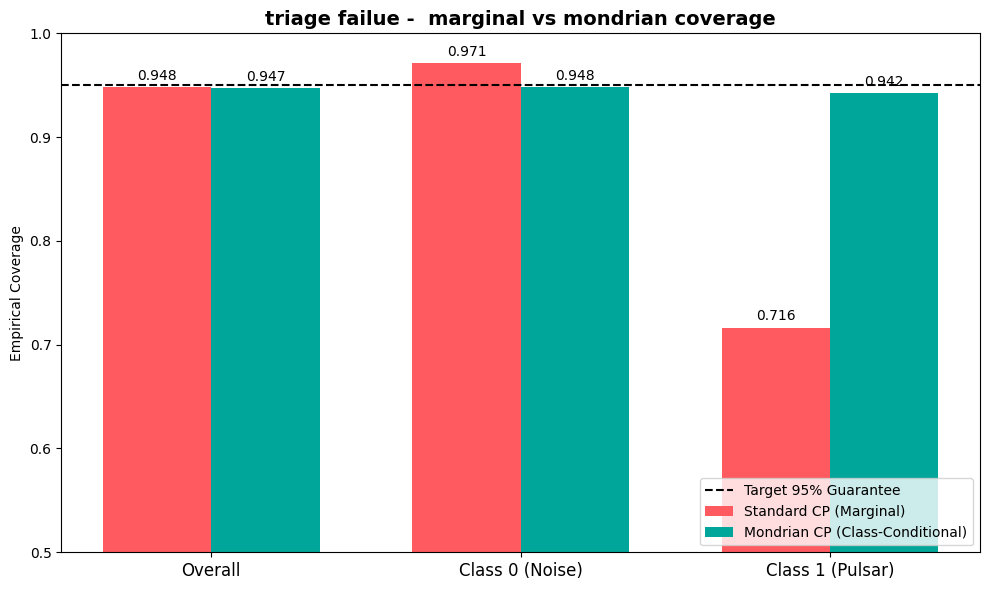

Standard ML - wasted Ops (FP): 25, missed pulsars (FN): 47
Mondrian CP - wasted Ops (FP): 169, missed pulsars (FN): 19, deferred: 319


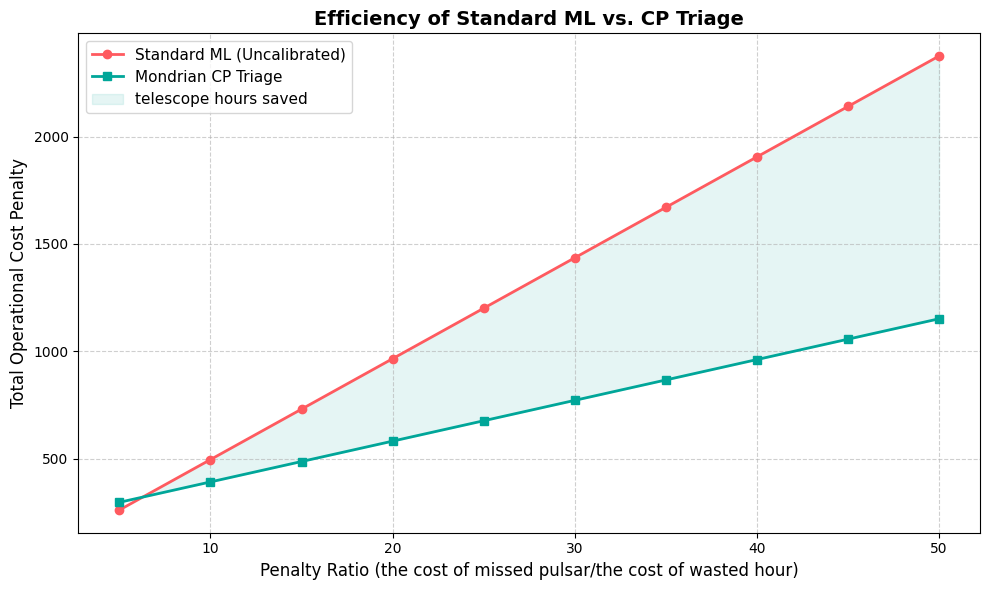

across all scenarios, Mondrian CP saves an average of 594.1 penalty units per survey batch compared to standard ML (while guaranteeing a 95% discovery rate).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from google.colab import drive
drive.mount('/content/drive')
processed='/content/drive/MyDrive/pulsar_project/data/processed'
try:
    trn_df=pd.read_csv(f"{processed}/train.csv")
    calib_df=pd.read_csv(f"{processed}/calib.csv")
    tst_df=pd.read_csv(f"{processed}/test.csv")
    print("success")
except FileNotFoundError:
    raise Exception("data not found")
x_train,y_train=trn_df.drop(columns=["target"]),trn_df["target"]
x_calib,y_calib=calib_df.drop(columns=["target"]),calib_df["target"]
x_test,y_test=tst_df.drop(columns=["target"]),tst_df["target"]
print("now we will train")
clf=lgb.LGBMClassifier(random_state=42,n_estimators=100,verbose=-1)
clf.fit(x_train,y_train)
calib_probs=clf.predict_proba(x_calib)
test_probs=clf.predict_proba(x_test)
print("probabilities are generated now we'll start caliberation")
print("caliberation")
calib_scores=1-calib_probs[np.arange(len(y_calib)),y_calib]
tstc=1-test_probs[np.arange(len(y_test)),y_test]
alpha=0.05
n=len(y_calib)
q_level=np.ceil((n+1)*(1-alpha))/n
marg_q=np.quantile(calib_scores,min(1.0,q_level))
marg_cov_0=np.mean(tstc[y_test==0]<=marg_q)
marg_cov_1=np.mean(tstc[y_test==1]<=marg_q)
marg_cov_overall=np.mean(tstc<=marg_q)
scores_0=calib_scores[y_calib==0]
scores_1=calib_scores[y_calib==1]
n_0=len(scores_0)
q_level_0=np.ceil((n_0+1)*(1-alpha))/n_0
q_0=np.quantile(scores_0,min(1.0,q_level_0))
n_1=len(scores_1)
q_level_1=np.ceil((n_1+1)*(1-alpha))/n_1
q_1=np.quantile(scores_1,min(1.0,q_level_1))
mdr_cov_0=np.mean(tstc[y_test==0]<=q_0)
mdr_cov_1=np.mean(tstc[y_test==1]<=q_1)
mdr_cov_overall=np.mean(tstc<=np.where(y_test==0,q_0,q_1))
labels=['Overall','Class 0 (Noise)','Class 1 (Pulsar)']
marg_bars=[marg_cov_overall,marg_cov_0,marg_cov_1]
mdr_bars=[mdr_cov_overall,mdr_cov_0,mdr_cov_1]
x=np.arange(len(labels))
width=0.35
fig,ax=plt.subplots(figsize=(10, 6))
rects1=ax.bar(x-width/2,marg_bars,width,label='Standard CP (Marginal)',color='#ff5a5f')
rects2=ax.bar(x+width/2,mdr_bars,width,label='Mondrian CP (Class-Conditional)',color='#00a699')
ax.axhline(y=0.95,color='black',linestyle='--',label='Target 95% Guarantee')
ax.set_ylabel('Empirical Coverage')
ax.set_title('triage failue -  marginal vs mondrian coverage',fontsize=14,fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=12)
ax.set_ylim(0.5,1.0)
ax.legend(loc='lower right')
for rect in rects1 + rects2:
    height=rect.get_height()
    ax.annotate(f'{height:.3f}',xy=(rect.get_x()+rect.get_width()/2,height),
                xytext=(0, 3),textcoords="offset points",ha='center',va='bottom',fontsize=10)
plt.tight_layout()
plt.show()
def gen_predsets(test_probs,q_0,q_1):
    inc_0=(1-test_probs[:,0])<=q_0
    inc_1=(1-test_probs[:,1])<=q_1
    labels=[]
    for i0, i1 in zip(inc_0,inc_1):
        if i0 and not i1:
            labels.append("discard (definitive noise)")
        elif not i0 and i1:
            labels.append("telescope (definitive pulsar)")
        elif i0 and i1:
            labels.append("defer (ambiguous)")
        else:
            labels.append("anomaly (empty set)")
    return np.array(labels)
triage_des=gen_predsets(test_probs,q_0,q_1)
rdf=pd.DataFrame({
    'true_label':y_test.values,
    'prob_pulsar':test_probs[:, 1],
    'triage_decision':triage_des
})
standard_preds=(test_probs[:,1]>=0.5).astype(int)
std_fp=np.sum((standard_preds==1)&(y_test==0))
std_fn=np.sum((standard_preds==0)&(y_test==1))
cp_fp=np.sum((rdf['triage_decision']=="telescope (definitive pulsar)")&(rdf['true_label']==0))
cp_fn=np.sum((rdf['triage_decision']=="discard (definitive noise)")&(rdf['true_label']==1))
cp_deferrals=np.sum(rdf['triage_decision']=="defer (ambiguous)")
print(f"Standard ML - wasted Ops (FP): {std_fp}, missed pulsars (FN): {std_fn}")
print(f"Mondrian CP - wasted Ops (FP): {cp_fp}, missed pulsars (FN): {cp_fn}, deferred: {cp_deferrals}")
cost_ratios=np.arange(5,51,5)
std_costs=[]
cp_costs=[]
cost_per_deferral=0.1
for cr in cost_ratios:
    cost_std=(std_fp*1)+(std_fn*cr)
    cost_cp=(cp_fp*1)+(cp_fn*cr)+(cp_deferrals*cost_per_deferral)
    std_costs.append(cost_std)
    cp_costs.append(cost_cp)
fig, ax=plt.subplots(figsize=(10,6))
ax.plot(cost_ratios,std_costs,marker='o',label='Standard ML (Uncalibrated)',color='#ff5a5f',linewidth=2)
ax.plot(cost_ratios,cp_costs,marker='s',label='Mondrian CP Triage',color='#00a699',linewidth=2)
ax.fill_between(cost_ratios,std_costs,cp_costs,where=(np.array(std_costs)>np.array(cp_costs)),interpolate=True,color='#00a699',alpha=0.1,label='telescope hours saved')
ax.set_xlabel('Penalty Ratio (the cost of missed pulsar/the cost of wasted hour)', fontsize=12)
ax.set_ylabel('Total Operational Cost Penalty',fontsize=12)
ax.set_title('Efficiency of Standard ML vs. CP Triage', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()
avg_savings=np.mean(np.array(std_costs)-np.array(cp_costs))
print(f"across all scenarios, Mondrian CP saves an average of {avg_savings:.1f} penalty units per survey batch compared to standard ML (while guaranteeing a 95% discovery rate).")